# Myntra Pants Price Prediction — Complete ML Pipeline
## Dataset: Myntra Pants Scraping Dataset
### Target: Predict Product Price (Regression)
---
**Pipeline includes:**
- Exploratory Data Analysis (Univariate, Bivariate, Multivariate)
- Feature Engineering
- Data Preprocessing & Encoding
- Multiple Regression Models
- Hyperparameter Tuning (GridSearchCV)
- Model Evaluation

# Task 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

# Task 2: Load the Dataset

In [3]:
df=pd.read_csv("C:\\Users\\User\\Downloads\\myntra_dataset_ByScraping (1).csv")
df_raw=df.copy() 
print('Shape:', df.shape)

Shape: (52120, 7)


In [4]:
df.head()

,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52120 entries, 0 to 52119
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         52120 non-null  object 
 1   pants_description  52120 non-null  object 
 2   price              52120 non-null  float64
 3   MRP                52120 non-null  float64
 4   discount_percent   52120 non-null  float64
 5   ratings            52120 non-null  float64
 6   number_of_ratings  52120 non-null  float64
dtypes: float64(5), object(2)
memory usage: 2.8+ MB


In [6]:
df.describe()

,price,MRP,discount_percent,ratings,number_of_ratings
count,52120.000000,52120.000000,52120.000000,52120.000000,52120.000000
mean,1594.515445,3180.398438,1.648256,3.997794,91.568937
std,1495.972325,2201.883218,4.687529,0.420404,433.918513
min,337.000000,499.000000,0.020000,1.000000,5.000000
25%,989.000000,2499.000000,0.400000,3.800000,16.000000
50%,1439.000000,2999.000000,0.500000,4.000000,35.000000
75%,1829.000000,3499.000000,0.630000,4.200000,74.000000
max,54000.000000,72000.000000,64.000000,5.000000,30700.000000


In [7]:
df.isnull().sum()

brand_name           0
pants_description    0
price                0
MRP                  0
discount_percent     0
ratings              0
number_of_ratings    0
dtype: int64

# Task 3: Exploratory Data Analysis (EDA)
## 3a: Univariate Analysis

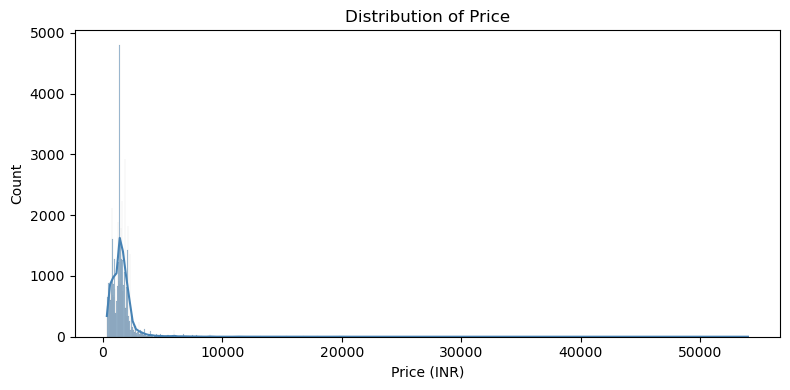

Price Stats:
count    52120.000000
mean      1594.515445
std       1495.972325
min        337.000000
25%        989.000000
50%       1439.000000
75%       1829.000000
max      54000.000000
Name: price, dtype: float64


In [8]:
# Target variable — Price distribution
plt.figure(figsize=(8,4))
sns.histplot(df['price'], kde=True, color='steelblue')
plt.title('Distribution of Price')
plt.xlabel('Price (INR)')
plt.tight_layout()
plt.show()

print('Price Stats:')
print(df['price'].describe())

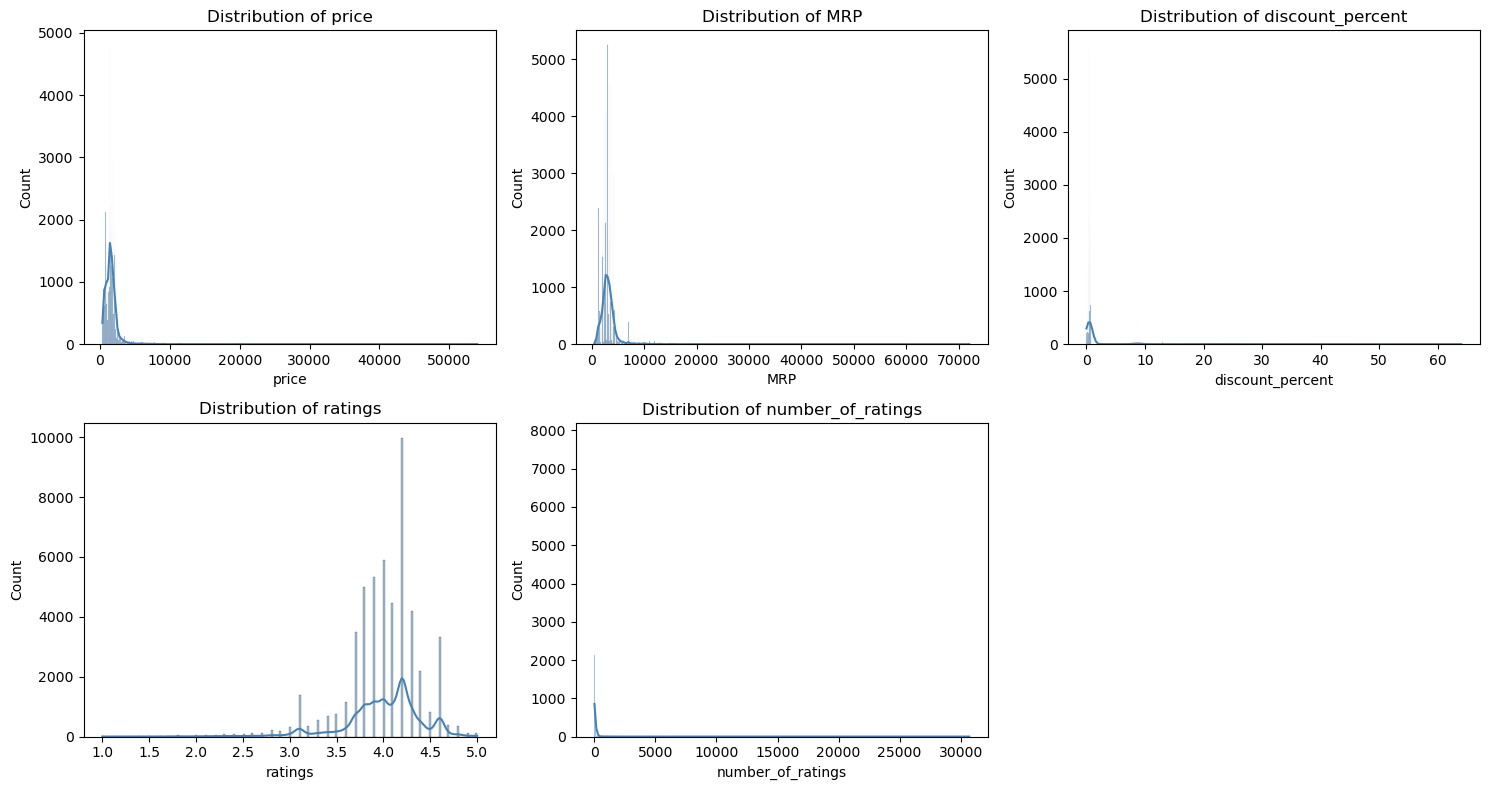

In [9]:
# Distribution of numerical columns
num_cols=['price','MRP','discount_percent','ratings','number_of_ratings']

plt.figure(figsize=(15,8))
for i, col in enumerate(num_cols,1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col],kde=True, color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

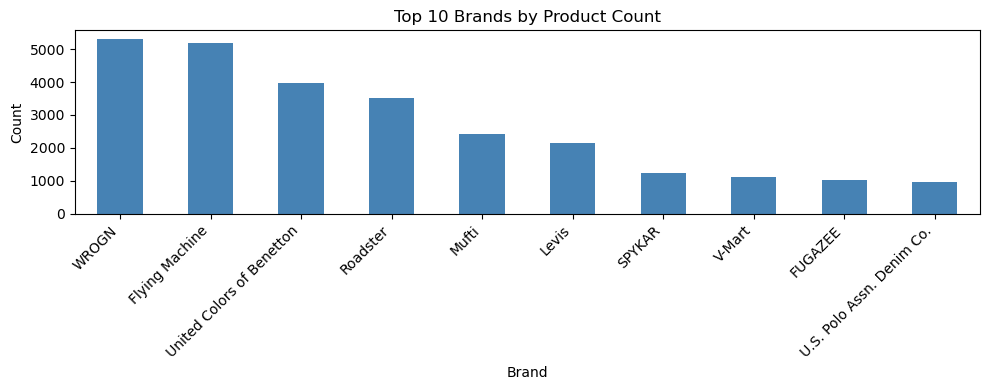

In [10]:
# Top 10 brands by count
plt.figure(figsize=(10,4))
df['brand_name'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Brands by Product Count')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

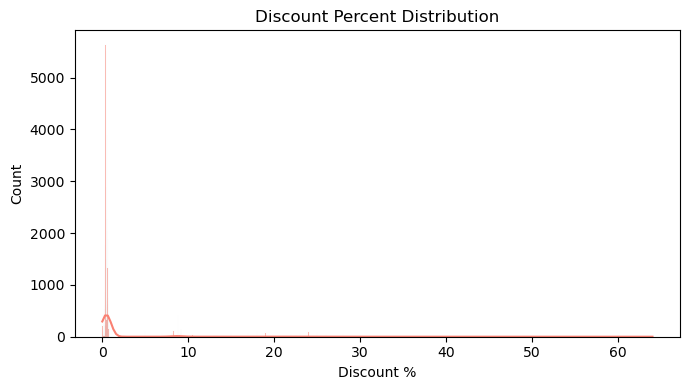

In [11]:
# Discount percent distribution
plt.figure(figsize=(7,4))
sns.histplot(df['discount_percent'], kde=True, color='salmon')
plt.title('Discount Percent Distribution')
plt.xlabel('Discount %')
plt.tight_layout()
plt.show()

## 3b: Bivariate Analysis

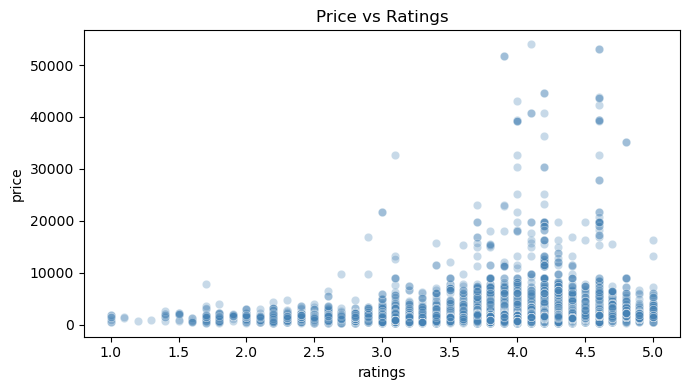

In [12]:
# Price vs Ratings
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x='ratings', y='price', alpha=0.3, color='steelblue')
plt.title('Price vs Ratings')
plt.tight_layout()
plt.show()

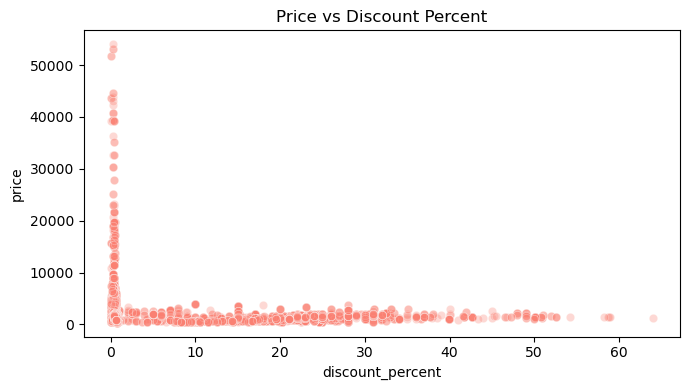

In [13]:
# Price vs Discount Percent
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x='discount_percent', y='price', alpha=0.3, color='salmon')
plt.title('Price vs Discount Percent')
plt.tight_layout()
plt.show()

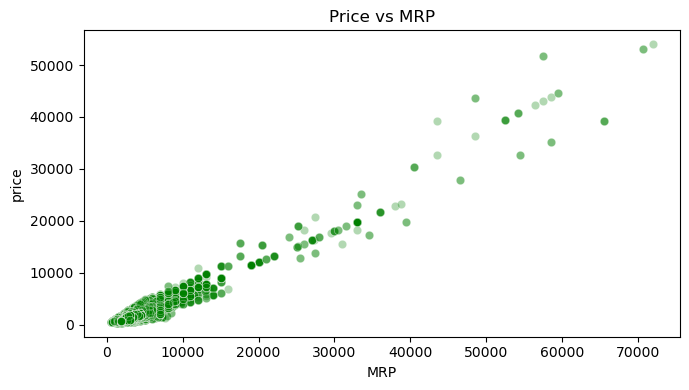

In [14]:
# Price vs MRP
plt.figure(figsize=(7,4))
sns.scatterplot(data=df, x='MRP', y='price', alpha=0.3, color='green')
plt.title('Price vs MRP')
plt.tight_layout()
plt.show()

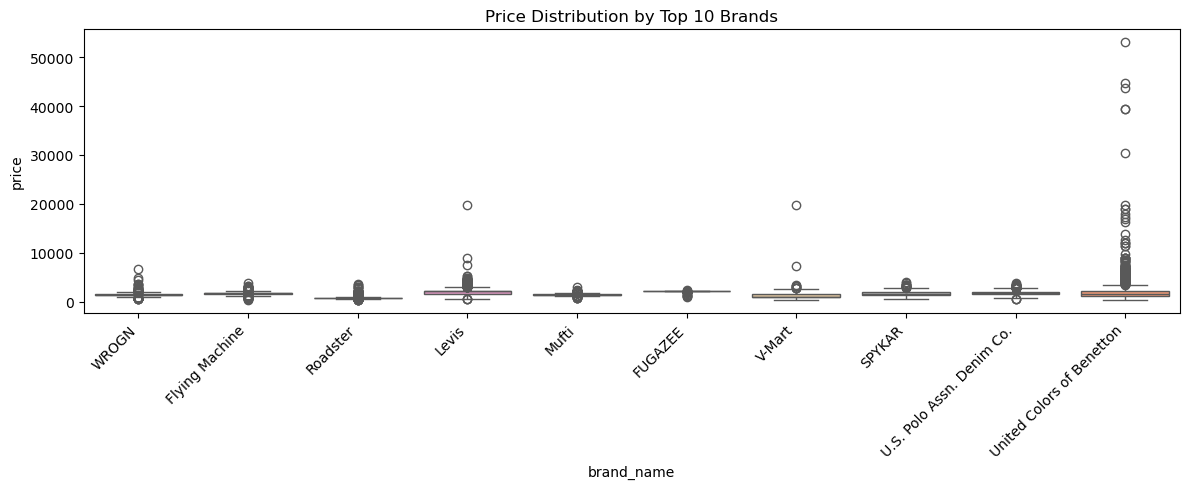

In [15]:
# Top 10 brands vs Average Price
top10 = df['brand_name'].value_counts().head(10).index
df_top = df[df['brand_name'].isin(top10)]

plt.figure(figsize=(12,5))
sns.boxplot(data=df_top, x='brand_name', y='price', palette='Set2')
plt.title('Price Distribution by Top 10 Brands')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

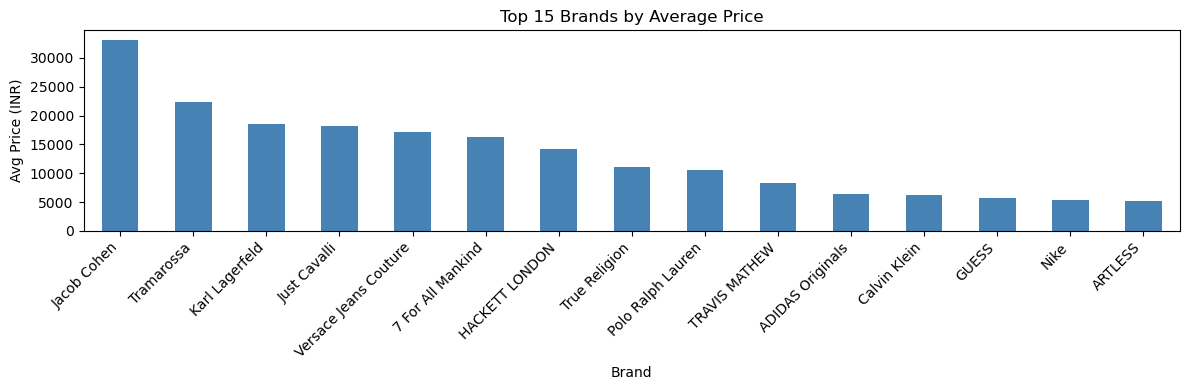

In [16]:
# Average price per brand (top 15)
avg_price = df.groupby('brand_name')['price'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,4))
avg_price.plot(kind='bar', color='steelblue')
plt.title('Top 15 Brands by Average Price')
plt.xlabel('Brand')
plt.ylabel('Avg Price (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3c: Multivariate Analysis

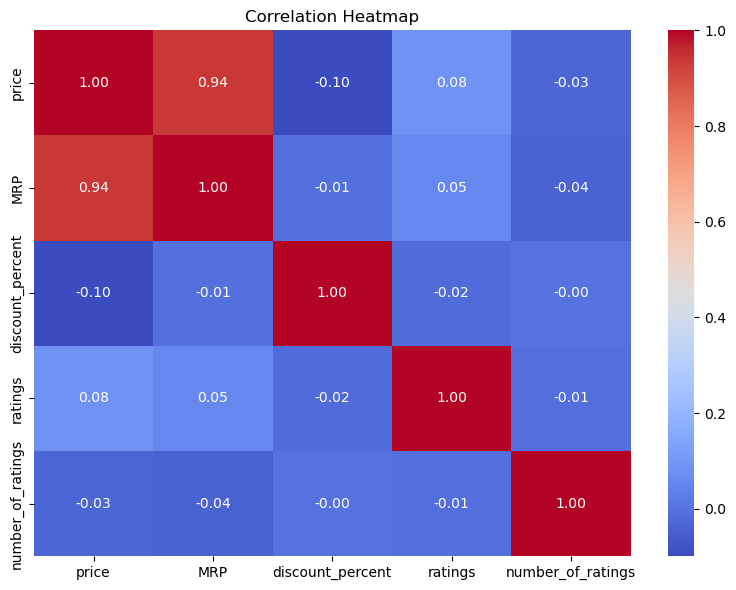

In [17]:
# Correlation Heatmap
num_df = df[['price', 'MRP', 'discount_percent', 'ratings', 'number_of_ratings']]

plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

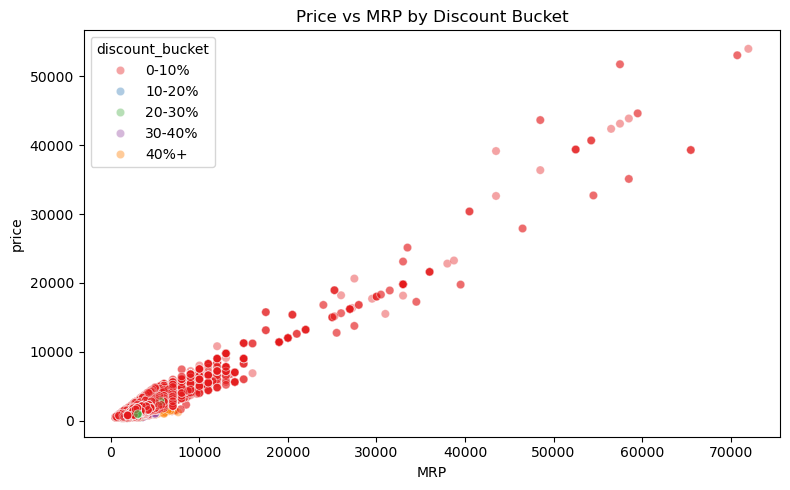

In [18]:
# Price vs MRP coloured by Discount bucket
df['discount_bucket']=pd.cut(df['discount_percent'],bins=[0,10,20,30,40,70],labels=['0-10%','10-20%','20-30%','30-40%','40%+'])

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='MRP', y='price', hue='discount_bucket',palette='Set1', alpha=0.4)
plt.title('Price vs MRP by Discount Bucket')
plt.tight_layout()
plt.show()

# Task 4: Feature Engineering
### Extract useful features from pants_description

In [19]:
# Extract fit type from description
def get_fit(desc):
    desc = desc.lower()
    if 'slim'      in desc: return 'Slim'
    elif 'loose'   in desc: return 'Loose'
    elif 'regular' in desc: return 'Regular'
    elif 'relaxed' in desc: return 'Relaxed'
    elif 'skinny'  in desc: return 'Skinny'
    elif 'wide'    in desc: return 'Wide'
    elif 'straight'in desc: return 'Straight'
    else: return 'Other'

# Extract fabric type
def get_fabric(desc):
    desc = desc.lower()
    if 'denim'   in desc: return 'Denim'
    elif 'cotton'in desc: return 'Cotton'
    elif 'linen' in desc: return 'Linen'
    elif 'polyester' in desc: return 'Polyester'
    else: return 'Other'

df['fit_type']    = df['pants_description'].apply(get_fit)
df['fabric_type'] = df['pants_description'].apply(get_fabric)

print('Fit Type distribution:')
print(df['fit_type'].value_counts())
print('\nFabric Type distribution:')
print(df['fabric_type'].value_counts())

Fit Type distribution:
fit_type
Slim        19185
Other       13421
Relaxed      5413
Skinny       4743
Regular      3982
Straight     2732
Loose        1518
Wide         1126
Name: count, dtype: int64

Fabric Type distribution:
fabric_type
Other     47148
Cotton     4710
Denim       262
Name: count, dtype: int64


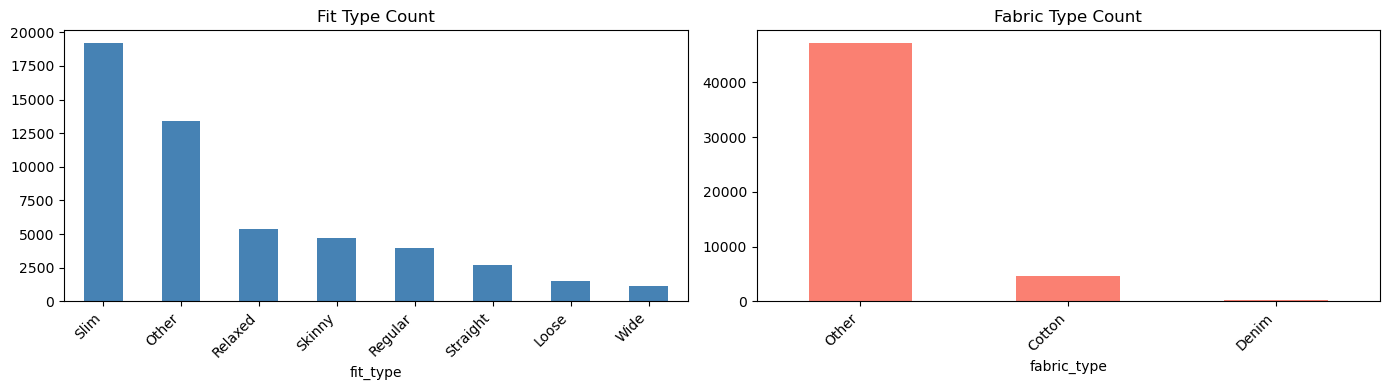

In [20]:
# Visualise new features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['fit_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Fit Type Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

df['fabric_type'].value_counts().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Fabric Type Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Task 5: Data Preprocessing
### Drop unused columns, encode categoricals

In [21]:
# Drop columns not useful for prediction
df=df.drop(['pants_description','discount_bucket'],axis=1)

print('Remaining columns:', df.columns.tolist())

Remaining columns: ['brand_name', 'price', 'MRP', 'discount_percent', 'ratings', 'number_of_ratings', 'fit_type', 'fabric_type']


In [22]:
# Label encode categorical columns
le=LabelEncoder()
cat_cols=['brand_name','fit_type','fabric_type']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('Encoding done!')
df.head()

Encoding done!


,brand_name,price,MRP,discount_percent,ratings,number_of_ratings,fit_type,fabric_type
0,391,1374.0,2499.0,0.45,4.2,57.0,0,0
1,130,1829.0,2999.0,0.39,4.6,5.0,5,2
2,300,974.0,2499.0,0.61,3.6,1100.0,1,0
3,49,873.0,2299.0,0.62,4.0,4800.0,3,1
4,210,1478.0,2899.0,0.49,4.3,264.0,5,2


# Task 6: Feature and Target Separation

In [23]:
# Target = price, Features = everything else
y = df['price']
X = df.drop('price', axis=1)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nFeatures:', X.columns.tolist())

X shape: (52120, 7)
y shape: (52120,)

Features: ['brand_name', 'MRP', 'discount_percent', 'ratings', 'number_of_ratings', 'fit_type', 'fabric_type']


# Task 7: Train-Test Split
- 80% Training
- 20% Testing
- random_state = 42

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test  shape:', y_test.shape)

X_train shape: (41696, 7)
X_test  shape: (10424, 7)
y_train shape: (41696,)
y_test  shape: (10424,)


# Task 8: Feature Scaling

In [27]:
num_features=X.columns.tolist()
transformer =ColumnTransformer([('scaler', StandardScaler(), num_features)])

X_train_trans=transformer.fit_transform(X_train)
X_test_trans =transformer.transform(X_test)

print('X_train_trans shape:', X_train_trans.shape)

X_train_trans shape: (41696, 7)


# Task 9: Train Multiple Regression Models
### Training 6 regressors and comparing performance

In [28]:
models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge'              : Ridge(),
    'Lasso'              : Lasso(),
    'ElasticNet'         : ElasticNet(),
    'Decision Tree'      : DecisionTreeRegressor(random_state=42),
    'Random Forest'      : RandomForestRegressor(random_state=42),
    'Gradient Boosting'  : GradientBoostingRegressor(random_state=42),
    'AdaBoost'           : AdaBoostRegressor(random_state=42),
    'KNN'                : KNeighborsRegressor(),
    'XGB'                : XGBRegressor(objective='reg:squarederror',n_estimators=100,learning_rate=0.1,random_state=42),
}

# Task 10: Fit and Predict All Models

In [29]:
results = []

for name, model in models.items():
    model.fit(X_train_trans, y_train)
    train_pred = model.predict(X_train_trans)
    test_pred  = model.predict(X_test_trans)
    results.append({
        'Model'    : name,
        'Train R2' : round(r2_score(y_train, train_pred), 4),
        'Test R2'  : round(r2_score(y_test,  test_pred),  4),
        'MAE'      : round(mean_absolute_error(y_test, test_pred), 2),
        'RMSE'     : round(np.sqrt(mean_squared_error(y_test, test_pred)), 2),
    })
    print(f'{name:<22} | Train R2: {r2_score(y_train,train_pred):.4f}'
          f' | Test R2: {r2_score(y_test,test_pred):.4f}'
          f' | MAE: {mean_absolute_error(y_test,test_pred):.2f}')

Linear Regression      | Train R2: 0.8924 | Test R2: 0.8747 | MAE: 355.50
Ridge                  | Train R2: 0.8924 | Test R2: 0.8747 | MAE: 355.50
Lasso                  | Train R2: 0.8924 | Test R2: 0.8748 | MAE: 355.32
ElasticNet             | Train R2: 0.7937 | Test R2: 0.8062 | MAE: 357.53
Decision Tree          | Train R2: 1.0000 | Test R2: 0.9957 | MAE: 5.00
Random Forest          | Train R2: 0.9994 | Test R2: 0.9958 | MAE: 5.75
Gradient Boosting      | Train R2: 0.9966 | Test R2: 0.9947 | MAE: 48.35
AdaBoost               | Train R2: 0.8616 | Test R2: 0.8288 | MAE: 436.46
KNN                    | Train R2: 0.9557 | Test R2: 0.9200 | MAE: 204.32
XGB                    | Train R2: 0.9875 | Test R2: 0.8940 | MAE: 47.12


# Task 11: Model Comparison Table

In [30]:
results_df=pd.DataFrame(results).sort_values('Test R2', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model  Train R2  Test R2    MAE   RMSE
    Random Forest    0.9994   0.9958   5.75  90.38
    Decision Tree    1.0000   0.9957   5.00  90.66
Gradient Boosting    0.9966   0.9947  48.35 101.40
              KNN    0.9557   0.9200 204.32 392.82
              XGB    0.9875   0.8940  47.12 452.06
            Lasso    0.8924   0.8748 355.32 491.28
            Ridge    0.8924   0.8747 355.50 491.45
Linear Regression    0.8924   0.8747 355.50 491.46
         AdaBoost    0.8616   0.8288 436.46 574.52
       ElasticNet    0.7937   0.8062 357.53 611.33


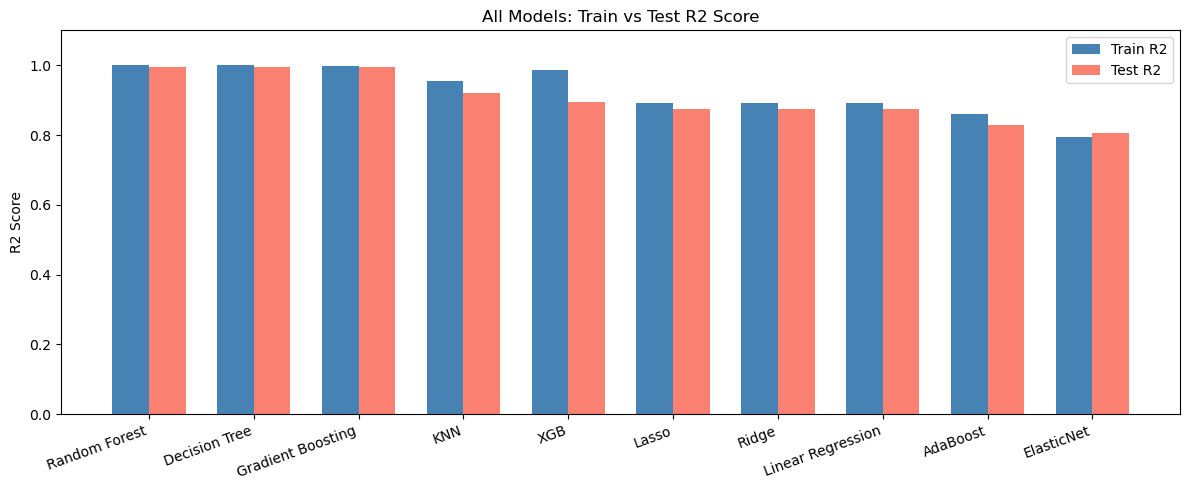

In [31]:
# Bar chart comparison
x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, results_df['Train R2'], width, label='Train R2', color='steelblue')
plt.bar(x + width/2, results_df['Test R2'],  width, label='Test R2',  color='salmon')
plt.xticks(x, results_df['Model'], rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.ylabel('R2 Score')
plt.title('All Models: Train vs Test R2 Score')
plt.legend()
plt.tight_layout()
plt.show()

# Task 12: Detailed Evaluation
### Actual vs Predicted plot for each model

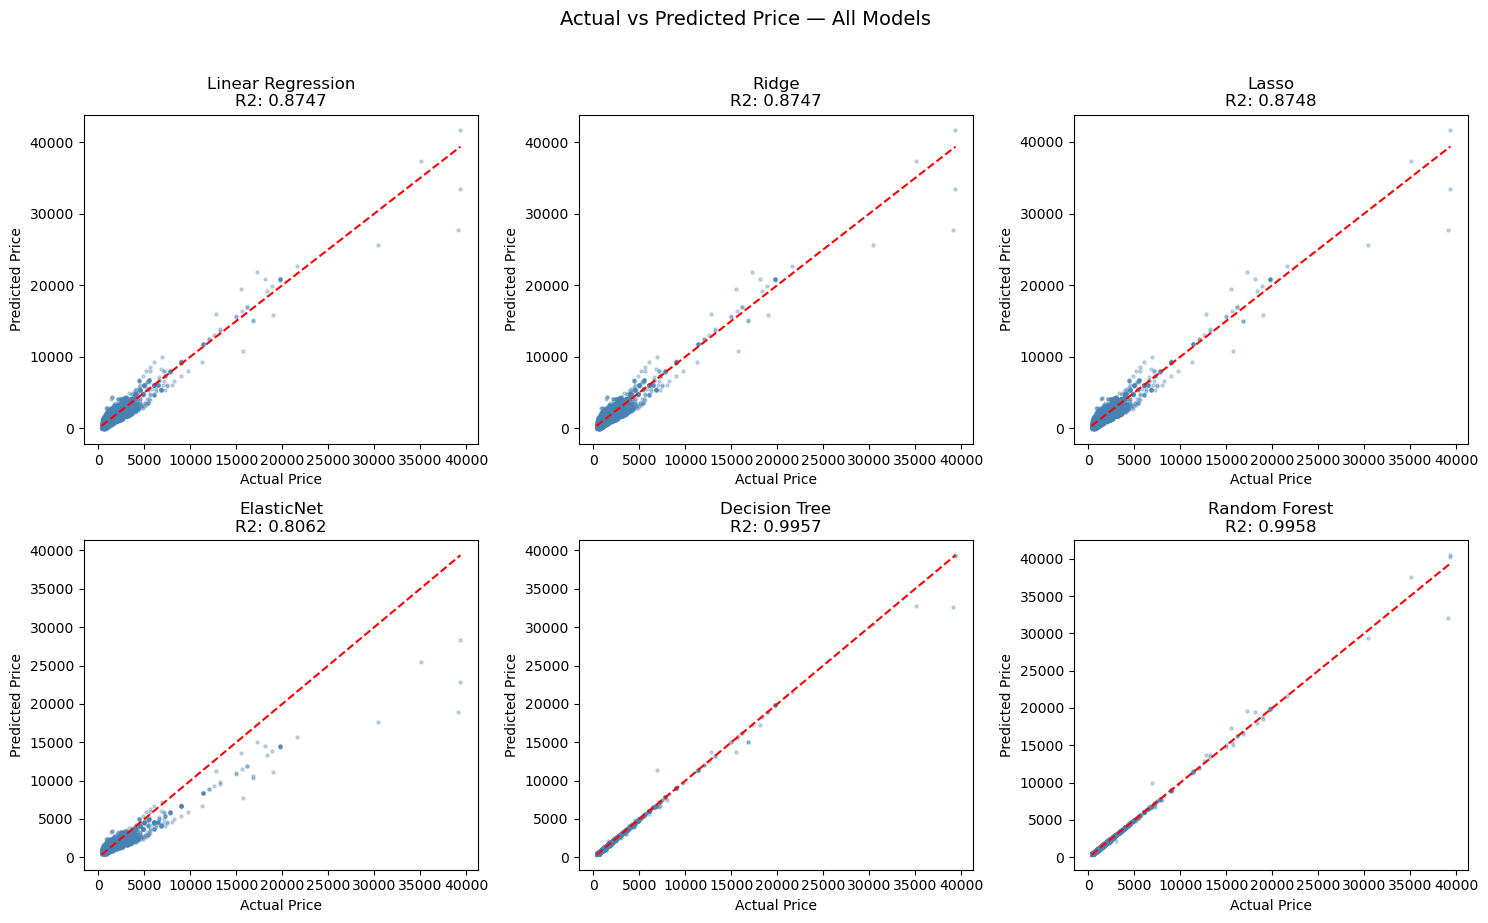

In [32]:
fig,axes =plt.subplots(2,3,figsize=(15, 9))
axes=axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    if idx>=6: break
    test_pred = model.predict(X_test_trans)
    axes[idx].scatter(y_test, test_pred, alpha=0.3, color='steelblue', s=5)
    axes[idx].plot([y_test.min(), y_test.max()],
                   [y_test.min(), y_test.max()], 'r--', lw=1.5)
    axes[idx].set_title(f'{name}\nR2: {r2_score(y_test, test_pred):.4f}')
    axes[idx].set_xlabel('Actual Price')
    axes[idx].set_ylabel('Predicted Price')

plt.suptitle('Actual vs Predicted Price — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Task 13: Cross Validation (5-Fold)

In [33]:
print(f'{"Model":<22} | {"Mean CV R2":>10} | {"Std":>6}')
print('-'*45)

for name, model in models.items():
    cv = cross_val_score(model, X_train_trans, y_train, cv=5, scoring='r2')
    print(f'{name:<22} | {cv.mean():.4f}     | {cv.std():.4f}')

Model                  | Mean CV R2 |    Std
---------------------------------------------
Linear Regression      | 0.8890     | 0.0156
Ridge                  | 0.8890     | 0.0156
Lasso                  | 0.8890     | 0.0156
ElasticNet             | 0.7931     | 0.0177
Decision Tree          | 0.9909     | 0.0054
Random Forest          | 0.9917     | 0.0017
Gradient Boosting      | 0.9935     | 0.0029
AdaBoost               | 0.8475     | 0.0325
KNN                    | 0.9269     | 0.0127
XGB                    | 0.9239     | 0.0331


# Task 14: Hyperparameter Tuning
### GridSearchCV on the best performing model

In [34]:
best_model_name = results_df.iloc[0]['Model']
print(f'Best model to tune: {best_model_name}')
print(f'Test R2 before tuning: {results_df.iloc[0]["Test R2"]}')

Best model to tune: Random Forest
Test R2 before tuning: 0.9958


In [35]:
param_grids = {
    'Linear Regression' : {},
    'Ridge'             : {'alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso'             : {'alpha': [0.001, 0.01, 0.1, 1.0]},
    'ElasticNet'        : {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]},
    'Decision Tree'     : {
        'max_depth'        : [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest'     : {
        'n_estimators'     : [50, 100, 200],
        'max_depth'        : [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting' : {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5]
    },
    'AdaBoost'          : {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    'Extra Trees'       : {
        'n_estimators'     : [50, 100, 200],
        'max_depth'        : [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'KNN'               : {
        'n_neighbors': [3, 5, 7, 11],
        'weights'    : ['uniform', 'distance']
    },
    'XGB'               : {
        'n_estimators' : [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5, 7]
    },
}

best_base_model=models[best_model_name]
best_param_grid=param_grids[best_model_name]

grid_search=GridSearchCV(best_base_model,best_param_grid,cv=3,scoring='r2',verbose=1,n_jobs=-1)

grid_search.fit(X_train_trans, y_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV R2 Score: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV R2 Score: 0.9907


# Task 15: Evaluate Tuned Best Model

In [36]:
tuned_model = grid_search.best_estimator_

y_train_tuned = tuned_model.predict(X_train_trans)
y_test_tuned  = tuned_model.predict(X_test_trans)

print(f'--- Tuned {best_model_name} ---')
print(f'Train R2 : {r2_score(y_train, y_train_tuned):.4f}')
print(f'Test  R2 : {r2_score(y_test,  y_test_tuned):.4f}')
print(f'MAE      : {mean_absolute_error(y_test, y_test_tuned):.2f}')
print(f'RMSE     : {np.sqrt(mean_squared_error(y_test, y_test_tuned)):.2f}')

--- Tuned Random Forest ---
Train R2 : 0.9995
Test  R2 : 0.9957
MAE      : 5.91
RMSE     : 91.46


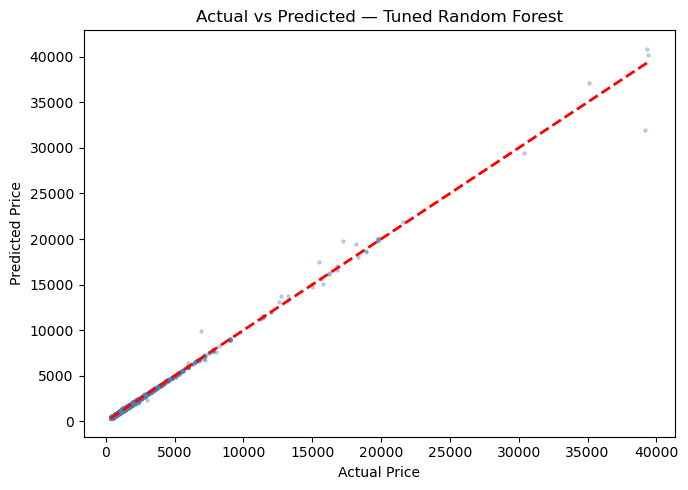

In [37]:
# Actual vs Predicted — Tuned model
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_test_tuned, alpha=0.3, color='steelblue', s=5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Actual vs Predicted — Tuned {best_model_name}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.show()

# Task 16: Feature Importance

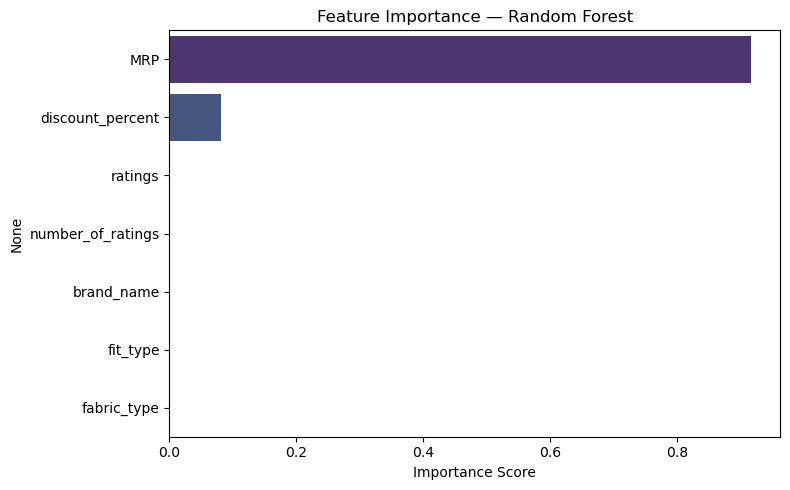


Top 5 Features:
MRP                  0.916698
discount_percent     0.080761
ratings              0.000901
number_of_ratings    0.000824
brand_name           0.000527
dtype: float64


In [38]:
if hasattr(tuned_model, 'feature_importances_'):
    fi = pd.Series(tuned_model.feature_importances_, index=X.columns)
    fi = fi.sort_values(ascending=False)

    plt.figure(figsize=(8,5))
    sns.barplot(x=fi.values, y=fi.index, palette='viridis')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print('\nTop 5 Features:')
    print(fi.head())
else:
    print(f'{best_model_name} does not support feature_importances_.')

# Task 17: Final Summary — Default vs Tuned

                  Model  Test R2  MAE
Random Forest (Default)   0.9958 5.75
  Random Forest (Tuned)   0.9957 5.91


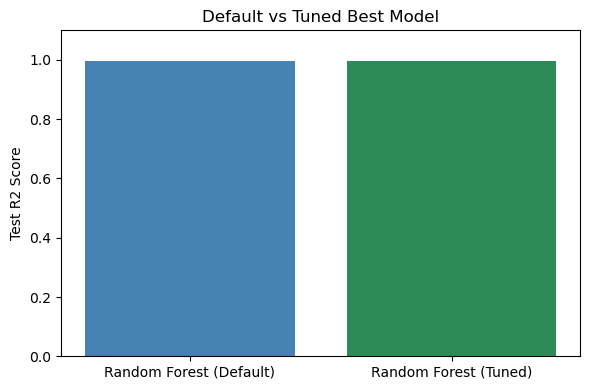

In [39]:
before_r2 = results_df.iloc[0]['Test R2']
after_r2  = round(r2_score(y_test, y_test_tuned), 4)

summary = pd.DataFrame({
    'Model'   : [f'{best_model_name} (Default)', f'{best_model_name} (Tuned)'],
    'Test R2' : [before_r2, after_r2],
    'MAE'     : [results_df.iloc[0]['MAE'],
                 round(mean_absolute_error(y_test, y_test_tuned), 2)]
})

print(summary.to_string(index=False))

plt.figure(figsize=(6,4))
plt.bar(summary['Model'], summary['Test R2'], color=['steelblue','seagreen'])
plt.ylim(0, 1.1)
plt.ylabel('Test R2 Score')
plt.title('Default vs Tuned Best Model')
plt.tight_layout()
plt.show()

# Task 18: Save Model as Pickle

In [40]:
import pickle

with open('myntra_price_best_model.pkl', 'wb') as f:
    pickle.dump(tuned_model, f)

with open('myntra_price_scaler.pkl', 'wb') as f:
    pickle.dump(transformer, f)

with open('myntra_price_encoders.pkl', 'wb') as f:
    # save label encoders for brand, fit_type, fabric_type
    enc = {}
    temp_df = df_raw.copy()
    temp_df['fit_type']    = temp_df['pants_description'].apply(get_fit)
    temp_df['fabric_type'] = temp_df['pants_description'].apply(get_fabric)
    for col in ['brand_name','fit_type','fabric_type']:
        le2 = LabelEncoder()
        le2.fit(temp_df[col])
        enc[col] = le2
    pickle.dump(enc, f)

print('All 3 pickle files saved!')
print('  myntra_price_best_model.pkl')
print('  myntra_price_scaler.pkl')
print('  myntra_price_encoders.pkl')

All 3 pickle files saved!
  myntra_price_best_model.pkl
  myntra_price_scaler.pkl
  myntra_price_encoders.pkl


---
## Pipeline Complete
- **Dataset**: 52,120 Myntra pants products · 7 original columns
- **Feature Engineering**: fit_type and fabric_type extracted from description
- **6 Regressors trained**: Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting
- **Best model auto-identified** by Test R2 score
- **GridSearchCV** applied for hyperparameter tuning
- **Evaluation**: R2, MAE, RMSE, Actual vs Predicted plots
- **Pickle files saved** for deployment